In [1]:
import hawkesbook as hawkes
import numpy as np

from multihawk import BaselineSpec, KernelSpec, simulate_hawkes

## MLE by hawkesbook (univariate exponential case)

In [2]:
# Simulate univariate Hawkes process by multihawk
rng = np.random.default_rng(0)
baseline = BaselineSpec(kind="constant", params={"values": [0.2]})
kernel = KernelSpec(kind="exponential", params={"beta": [[2.0]]})
alpha = [[0.4]]
T = 10000
data = simulate_hawkes(t_max=T, baseline=baseline, alpha=alpha, kernel=kernel, rng=rng)

# Estimate parameters using MLE from hawkesbook

# parameters in hawkesbook format
# See https://github.com/Pat-Laub/hawkesbook/blob/main/hawkesbook/hawkes.py#L36
lambda_in_book = baseline.params["values"][0]
alpha_in_book = alpha[0][0] * kernel.params["beta"][0][0]
beta_in_book = kernel.params["beta"][0][0]

# Print results
print("Parameters used to simulate the Hawkes process:")
print(f"  lambda: {lambda_in_book}, alpha: {alpha_in_book}, beta: {beta_in_book}")

mle = hawkes.exp_mle(data.timestamps[0], T)
print("Parameters estimated by MLE in hawkesbook:")
print(f"  lambda: {mle[0]}, alpha: {mle[1]}, beta: {mle[2]}")

em = hawkes.exp_em(np.array(data.timestamps[0]), T)
print("Parameters estimated by EM in hawkesbook:")
print(f"  lambda: {em[0]}, alpha: {em[1]}, beta: {em[2]}")

Parameters used to simulate the Hawkes process:
  lambda: 0.2, alpha: 0.8, beta: 2.0
Parameters estimated by MLE in hawkesbook:
  lambda: 0.1989143971712066, alpha: 0.7861792396313212, beta: 2.026466993483925
Parameters estimated by EM in hawkesbook:
  lambda: 0.19891431880855043, alpha: 0.7861758419101235, beta: 2.026456503279117


## MLE by sparklen (5-variate exponential case)

In [3]:
from sparklen.hawkes.inference import LearnerHawkesExp
from sparklen.plot import plot_values


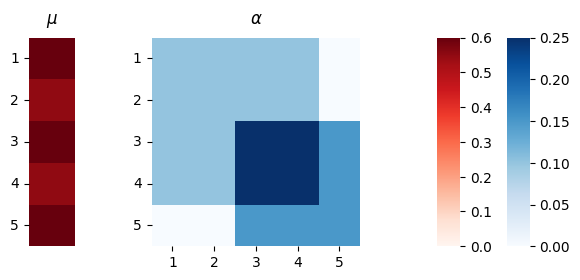

Optimizing:  15%|█▌        | 30/200 [00:00<00:00, 716.73it/s, Loss=3.03e+3, Step Size=0.000122] 


Optimization completed. Convergence achieved after 25 iterations.

Time elapsed: 0.16 seconds.
+-------------+---------+-------------+
|   Iteration |    Loss |   Tolerance |
+=============+=========+=============+
|           0 | 3239.11 | 0.0975001   |
+-------------+---------+-------------+
|          10 | 3032.14 | 0.00054882  |
+-------------+---------+-------------+
|          20 | 3027.82 | 2.05124e-05 |
+-------------+---------+-------------+
[[0.53917029 0.05491338 0.09676788 0.10411581 0.11173984 0.01833508]
 [0.49960758 0.07430892 0.11679516 0.13628371 0.09540042 0.        ]
 [0.6912124  0.10095487 0.04807394 0.28466805 0.23809722 0.12436276]
 [0.61562377 0.06610239 0.04794959 0.25285682 0.24521789 0.17023181]
 [0.56502539 0.         0.         0.16703058 0.15686245 0.1221506 ]]


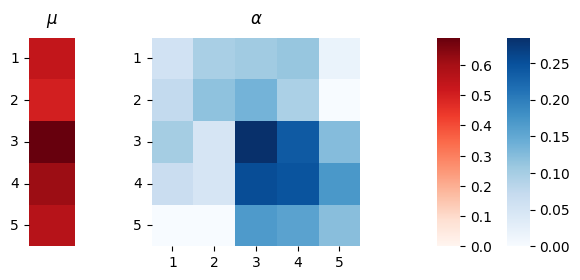

In [ ]:
d = 5
beta = 3.0
mu = np.array([0.6, 0.55, 0.6, 0.55, 0.6])
alpha = np.zeros((d,d))
alpha[:4, :4] += 0.1
alpha[2:, 2:] += 0.15

baseline = BaselineSpec(kind="constant", params={"values": mu})
kernel = KernelSpec(kind="exponential", params={"beta": [[beta]*d]*d})

T = 1000
data = simulate_hawkes(t_max=T, baseline=baseline, alpha=alpha, kernel=kernel, rng=rng)


theta_star = np.hstack([np.reshape(mu, (d,-1)), alpha])

plot_values(theta_star)

learner = LearnerHawkesExp(
    decay=beta, loss='log-likelihood', penalty="none",
    optimizer="agd", lr_scheduler="backtracking",
    max_iter=200, tol=1e-5,
    verbose_bar=True, verbose=True,
    print_every=10, record_every=10
)

learner.fit([[np.array(data.timestamps[i]) for i in range(d)]], end_time=T)

print(learner.estimated_params)

learner.plot_estimated_values()

## MLE by omitakahiro/hawkes (piecewise constant intensity)

In [5]:
import Hawkes as hk

In [6]:
mu = [0.1, 0.3, 0.1]
alpha = 0.2
weights = [0.6, 0.4]
beta = [0.5, 2.0]

hk_true_vals = {
    'mu': mu,
    'alpha': [alpha * w for w in weights],
    'beta': beta
}
T = 100000

In [7]:
rng = np.random.default_rng(0)
baseline = BaselineSpec(
    kind="piecewise_linear",
    params={
        "breaks": [0.0, T/2, T],
        "values": [mu],
    },
)
kernel = KernelSpec(
    kind="mixed_exponential",
    params={
        "weights": [[weights]],
        "beta": [[beta]],
    },
)
alpha = [[alpha]]

data = simulate_hawkes(
    t_max=T,
    baseline=baseline,
    alpha=alpha,
    kernel=kernel,
    rng=rng,
).timestamps[0]

In [8]:
itv = [0, T]
# in plinear, the breakpoints are equally spaced
model = hk.estimator().set_kernel('exp', num_exp=2).set_baseline('plinear', num_basis=3)
model.fit(data, itv)
print("Estimated value:", model.para)
print("True value:", hk_true_vals)

Estimated value: {'mu': array([0.09859405, 0.29995309, 0.0995553 ]), 'alpha': array([0.11511531, 0.07700534]), 'beta': array([0.49855052, 2.01444516])}
True value: {'mu': [0.1, 0.3, 0.1], 'alpha': [0.12, 0.08000000000000002], 'beta': [0.5, 2.0]}
